# Milestone 1 – Data Collection & Exploratory Data Analysis  
## Smart Energy Consumption Analysis and Prediction using Machine Learning  

**Intern Name:** Kunal Bhardwaj  
**GitHub Branch:** kunal_branch  
**Dataset:** Individual Household Electric Power Consumption  

### Objective
The objective of this milestone is to understand the energy consumption dataset in depth.
This includes loading the dataset, understanding each variable, handling timestamps,
and performing exploratory data analysis (EDA) to identify trends, missing values,
and potential anomalies.

No modeling or aggressive preprocessing is performed at this stage.
The focus is purely on data understanding and insight generation.


## Project Scope & Problem Definition

This project analyzes historical electricity consumption data
recorded at device-level granularity over time.

Energy consumption here refers to the amount of electrical power
used (in kilowatts) by household devices across time intervals.

The goal is to:
1. Understand temporal energy usage patterns
2. Identify high-consumption periods
3. Predict future energy consumption


## 1. Import Required Libraries


In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
sns.set_style('whitegrid')

print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Dataset Loading

The household power consumption dataset is loaded from the local data directory.  
Missing values represented by `?` are treated as NaN.


In [2]:
import pandas as pd
import os

file_path = "../data/household_power_consumption.txt"

print(os.path.exists(file_path))  # Should print True

df = pd.read_csv(
    file_path,
    sep=';',
    parse_dates=[[0, 1]],
    infer_datetime_format=True,
    na_values=['?']
)


True


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18880\1676406495.py:8: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18880\1676406495.py:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18880\1676406495.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


## 3. Datetime Processing

The Date and Time columns are combined into a single DateTime index
to enable time-series analysis.


In [3]:
df.rename(columns={'Date_Time': 'DateTime'}, inplace=True)
df.set_index('DateTime', inplace=True)

df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 4. Missing Value Analysis and Handling

Missing values are analyzed and handled using forward fill, which is appropriate for continuous time-series data.


In [3]:
# Check missing values
print(df.isna().sum())

# Fill missing values with forward fill
df.fillna(method='ffill', inplace=True)

# Verify no missing values
print(df.isna().sum())


Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19992\995422516.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


## 5. Exploratory Data Analysis (EDA)

This section explores energy consumption patterns over time and across different household sub-meters.


In [1]:
plt.figure(figsize=(15,5))
df['Global_active_power'].plot(title='Global Active Power over Time', color='blue')
plt.xlabel('DateTime')
plt.ylabel('Global Active Power (kW)')
plt.show()


NameError: name 'plt' is not defined

**Observation:** Energy usage shows clear temporal variation with visible peaks.


<Figure size 1500x500 with 0 Axes>

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


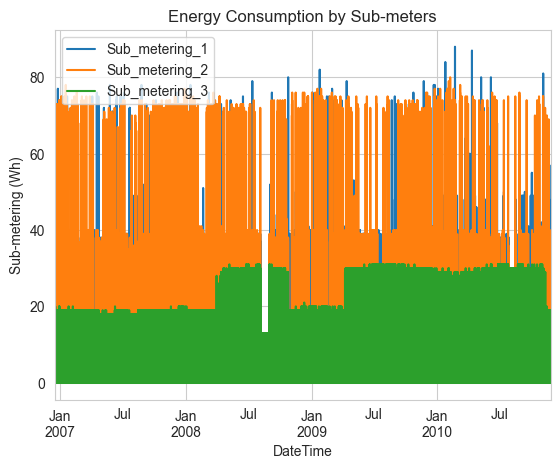

In [5]:
plt.figure(figsize=(15,5))
df[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].plot()
plt.title('Energy Consumption by Sub-meters')
plt.xlabel('DateTime')
plt.ylabel('Sub-metering (Wh)')
plt.legend()
plt.show()


## 6. Summary and Key Insights

- Dataset contains over 2 million time-stamped records.
- Missing values were handled appropriately.
- Clear consumption patterns are observed over time.
- Data is now ready for feature engineering and modeling.
